Accuracy :  0.975


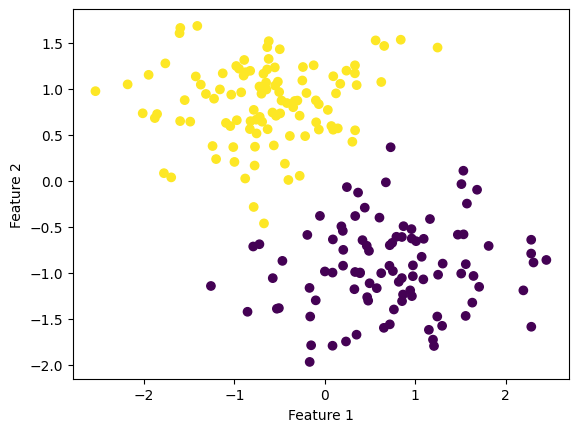

In [5]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

class perceptron :
    def __init__(self, num_inputs, learning_rate=0.01):
        #initialize the weights
        self.weights = np.random.rand(num_inputs + 1) #random initialization
        self.learning_rate = learning_rate
    def linear(self, inputs):
        #performs a linear transformation by dot product of inputs with weights matrix
        Z = inputs @ self.weights[1:].T + self.weights[0]  #weighted sum : XW + B
        return Z
    def heaviside(self,Z):
        if Z >= 0:
            return 1
        else:
            return 0
    def predict(self, inputs):
        Z = self.linear(inputs)
        try :
            pred = []
            for z in Z:
                pred.append(self.heaviside(z))
        except :
            return self.heaviside(Z)
        return pred
    def loss(self, prediction, target):
        loss = (prediction - target)
        return loss
     #Define training
    def train(self, inputs, target):
        prediction = self.predict(inputs)
        error = self.loss(prediction, target)
        self.weights[1:] += self.learning_rate * error * inputs
        self.weights[0]  += self.learning_rate * error

    # Fit the model
    def fit(self, X, y, num_epochs):
        for epoch in range(num_epochs):
            for inputs, target in zip(X, y):
                self.train(inputs, target)


x,y = make_blobs(n_samples=1000, n_features=2, centers=2, cluster_std=3, random_state=23)
x_train , x_test, y_train ,  y_test = train_test_split(x,y, test_size=0.2, random_state=23, shuffle=True)
Scaler =  StandardScaler()
x_train = Scaler.fit_transform(x_train)
x_test = Scaler.fit_transform(x_test)

np.random.seed(23)

perceptron = perceptron(num_inputs=x_train.shape[1])

perceptron.fit(x_train,y_train,num_epochs=100)

pred = perceptron.predict(x_test)
accuracy = np.mean(pred != y_test)
print("Accuracy : ", accuracy)

#plot the dataset
plt.scatter(x_test[:,0],x_test[:,1],c=pred)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()
